# Notebook 03 - Glare Detection

**Method:** HSV V-channel Intensity Thresholding

**How it works:**
1. Convert BGR image to HSV color space
2. Extract V (Value / Brightness) channel
3. Count pixels where V > 240 (overexposed)
4. **If >10% of pixels are glare pixels → reject**

**Why HSV?** RGB mixes brightness with color. HSV separates them — V channel = pure brightness.

**Research:** arXiv:1911.05189 "Fast Glare Detection"

**Speed:** ~3ms per image on CPU

In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.glare  import compute_glare_ratio, has_glare, get_glare_label
from src.config import DATASET_ROOT, IMAGE_EXTENSIONS, GLARE_THRESHOLD, GLARE_V_VALUE

## 1. Visualise the HSV V-Channel

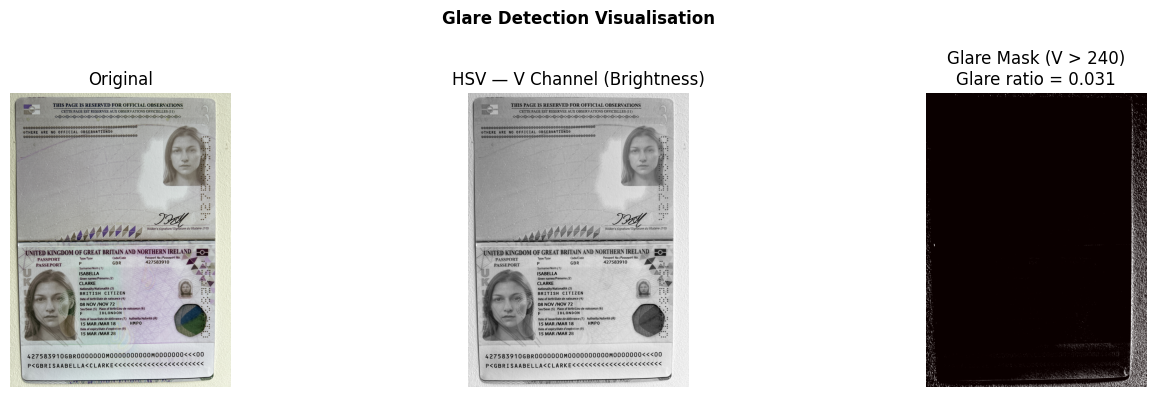

In [2]:
all_images = [p for p in Path(DATASET_ROOT).rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS]
img_path   = all_images[0]

img = cv2.imread(str(img_path))
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
v   = hsv[:, :, 2]

# Create glare mask
glare_mask = (v > GLARE_V_VALUE).astype(np.uint8) * 255
ratio = compute_glare_ratio(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(v, cmap='gray')
axes[1].set_title('HSV — V Channel (Brightness)')
axes[2].imshow(glare_mask, cmap='hot')
axes[2].set_title(f'Glare Mask (V > {GLARE_V_VALUE})\nGlare ratio = {ratio:.3f}')

for ax in axes: ax.axis('off')
plt.suptitle('Glare Detection Visualisation', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Glare Ratio Distribution Across Dataset

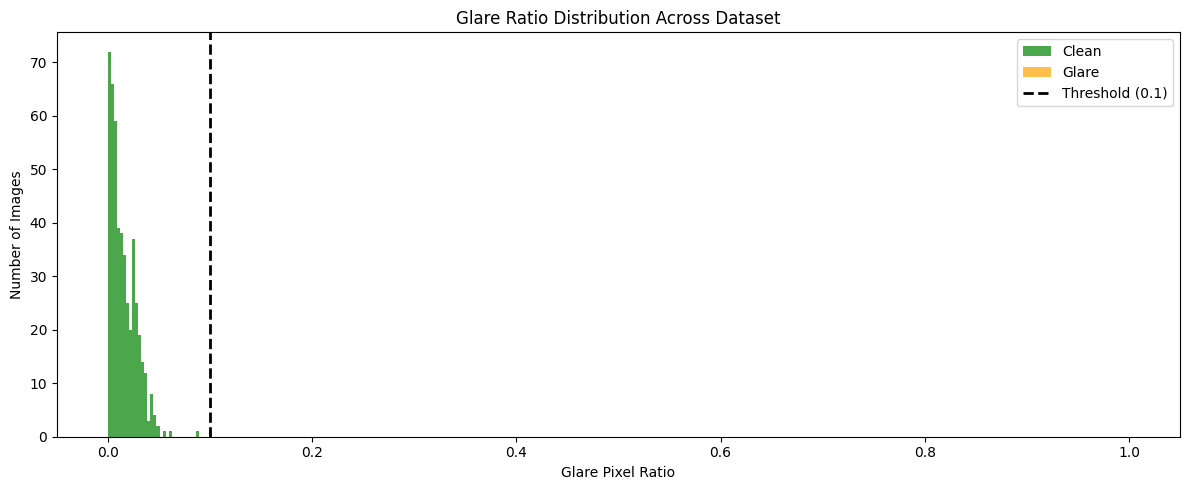

Clean: 480 images (100%)
Glare: 0 images (0%)


In [3]:
ratios = []
labels = []

for img_path in all_images:
    img = cv2.imread(str(img_path))
    if img is None: continue
    ratio, glare = has_glare(img)
    ratios.append(ratio)
    labels.append('Glare' if glare else 'Clean')

clean_ratios = [r for r, l in zip(ratios, labels) if l == 'Clean']
glare_ratios = [r for r, l in zip(ratios, labels) if l == 'Glare']

plt.figure(figsize=(12, 5))
plt.hist(clean_ratios, bins=30, alpha=0.7, color='green', label='Clean')
plt.hist(glare_ratios, bins=30, alpha=0.7, color='orange', label='Glare')
plt.axvline(GLARE_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold ({GLARE_THRESHOLD})')
plt.xlabel('Glare Pixel Ratio')
plt.ylabel('Number of Images')
plt.title('Glare Ratio Distribution Across Dataset')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Clean: {len(clean_ratios)} images ({100*len(clean_ratios)//len(ratios)}%)')
print(f'Glare: {len(glare_ratios)} images ({100*len(glare_ratios)//len(ratios)}%)')

## 3. Which Lighting Condition Has Most Glare?

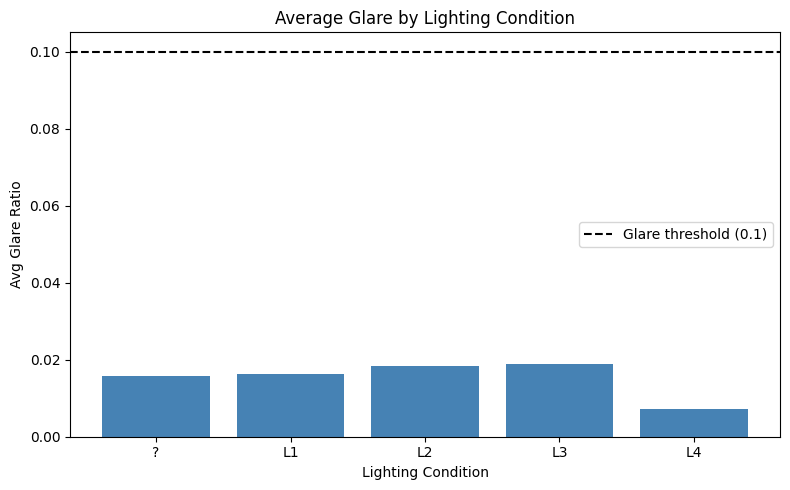

In [4]:
from collections import defaultdict
from src.parser import parse_filename

lighting_glare = defaultdict(list)

for img_path in all_images:
    img = cv2.imread(str(img_path))
    if img is None: continue
    ratio = compute_glare_ratio(img)
    meta  = parse_filename(img_path.name)
    lighting_glare[meta['lighting']].append(ratio)

avg_glare = {k: np.mean(v) for k, v in sorted(lighting_glare.items())}

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_glare.keys(), avg_glare.values(),
               color=['red' if v > GLARE_THRESHOLD else 'steelblue' for v in avg_glare.values()])
plt.axhline(GLARE_THRESHOLD, color='black', linestyle='--', label=f'Glare threshold ({GLARE_THRESHOLD})')
plt.xlabel('Lighting Condition')
plt.ylabel('Avg Glare Ratio')
plt.title('Average Glare by Lighting Condition')
plt.legend()
plt.tight_layout()
plt.show()